# 中国主要城市公共预算支出和收入数据分析
## 作业编号：ex_Team01
## 项目描述：
   - 小组编号：7
   - 小组成员：许冠豪，邝思翀，吴奕敏，林少芳，蔡小玉，林艾嘉，吴钰，宋雅诗

# 以下是本次作业的整体思路与框架构建：

## 1. 数据预处理与合并 (Data Preprocessing & Merging)
- **数据读取**：使用 `pandas.read_excel` 分别读取 `city_income.xlsx`, `city_expenditure.xlsx`, `gdp.xlsx`, `individual_deposit.xlsx` 以及房地产相关的各个Excel文件。
- **数据清洗**：
  - 处理国家统计局下载数据中常见的表头格式问题（如多级表头、无用空行等）。
  - 将宽表（年份为列）转换为长表（年份为行的一列），统一格式为 `[city, year, value]`。
  - 处理缺失值（如插值法或直接剔除，视缺失情况而定）和异常值。
  - 统一城市名称格式（去除“市”字等后缀，确保合并键一致）。
- **数据合并**：以 `city` 和 `year` 为主键，使用 `pd.merge` 将所有指标合并为一个统一的数据框（DataFrame）。

## 2. 指标计算与特征工程 (Feature Engineering)
- **预算缺口计算**：生成新变量 `gap = expend - income`。
- **缺口率计算**：生成新变量 `gap_to_gdp = gap / gdp`。
- **增长率计算**：按城市分组（`groupby('city')`），使用 `pct_change()` 计算 `income` 和 `expend` 的年度增长率。

## 3. 极值提取与列表呈现 (Extremes & Tabulation)
- 筛选出特定年份（2006, 2010, 2014, 2018, 2022）。
- 在每个特定年份中，按 `gap_to_gdp` 排序，提取最大和最小的城市。
- 格式化输出为清晰的表格。

## 4. 统计与可视化分析 (Statistical & Visual Analysis)
- **一线城市对比**：提取北上广深（北京、上海、广州、深圳）的数据，绘制时间序列折线图，对比其 `gap_to_gdp` 的演变趋势。
- **城市群对比（长三角 vs 珠三角）**：
  - 构建城市分组字典（如长三角包含上海、南京、杭州、合肥等；珠三角包含广州、深圳、珠海、佛山等）。
  - 分组聚合计算各城市群的平均 `gap_to_gdp`，绘制对比图表，并进行均值差异的统计检验（如T检验）。

## 5. 房地产视角的深入分析 (Real Estate Perspective)
- **数据整合**：将之前预处理好的房地产指标（投资额、销售面积、均价、土地购置等）与主数据框合并。
- **相关性分析**：计算 `gap_to_gdp` 与各项房地产指标的相关系数矩阵，绘制热力图。
- **时序特征与地区差异**：
  - 选取代表性指标（如土地购置面积 `re_land_purchase_area` 或商品房销售面积 `re_sales_area`），分析其与地方财政缺口的动态关系（例如土地财政依赖度对预算缺口的缓解作用）。
  - 使用散点图和回归拟合线，展示不同城市群在房地产依赖度与财政缺口上的异质性。

---
# STEP_1
## 数据预处理与合并
## 处理思路
   - 国家统计局下载的数据通常为“宽表”格式（即第一列为城市，后续各列为不同年份的数据），且往往带有单位说明、多级表头或底部的注释行。为了进行后续的计算与分析，需要将其转换为“长表”格式（包含 city, year, value），并对城市名称和年份字段进行标准化清洗，以确保合并主键的完全一致。

In [4]:
import pandas as pd
import numpy as np
import os
import re

# 定义项目目录路径
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
RAW_DATA_DIR = os.path.join('..', 'data_raw')
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')

def process_nbs_excel(file_name, value_col_name):
    """
    处理国家统计局下载的Excel宽表数据（带自动表头识别与脏数据过滤）
    """
    file_path = os.path.join(RAW_DATA_DIR, file_name)
    
    # 1. 自动寻找表头行：读取前几行，寻找包含多个年份特征（如 2022）的行
    df_raw = pd.read_excel(file_path, header=None, nrows=10)
    header_idx = 0
    for i in range(len(df_raw)):
        row_str = ' '.join(df_raw.iloc[i].astype(str).tolist())
        # 如果某行包含至少3个年份数字（20xx），则判定为真实表头
        if len(re.findall(r'20\d{2}', row_str)) >= 3:
            header_idx = i
            break
            
    # 2. 按正确的表头重新读取数据
    df = pd.read_excel(file_path, skiprows=header_idx)
    
    # 3. 清理非数据行（如底部的“数据来源：国家统计局”、“注：...”等）
    first_col = df.columns[0]
    df = df.dropna(subset=[first_col])
    # 剔除第一列包含特定非城市关键字的行
    df = df[~df[first_col].astype(str).str.contains('注|来源|统计局|指标|时间')]
    
    # 重命名第一列为 city
    df.rename(columns={first_col: 'city'}, inplace=True)
    
    # 4. 宽表转长表
    df_long = df.melt(id_vars=['city'], var_name='year', value_name=value_col_name)
    
    # 5. 提取年份并清洗
    df_long['year'] = df_long['year'].astype(str).str.extract(r'(\d{4})')
    df_long = df_long.dropna(subset=['year'])  # 剔除无法提取年份的无效列
    df_long['year'] = df_long['year'].astype(int)
    
    # 6. 清洗城市名称（去空格、去“市”字）
    df_long['city'] = df_long['city'].astype(str).str.replace(r'\s+', '', regex=True)
    df_long['city'] = df_long['city'].str.replace('市', '')
    
    # 7. 数值化处理（将非数字字符转为 NaN）
    df_long[value_col_name] = pd.to_numeric(df_long[value_col_name], errors='coerce')
    
    return df_long

# 核心文件与变量名映射
core_files = {
    'city_income.xlsx': 'income',
    'city_expenditure.xlsx': 'expend',
    'gdp.xlsx': 'gdp'
}

merged_df = None

# 执行读取、清洗与合并
for file_name, col_name in core_files.items():
    file_path = os.path.join(RAW_DATA_DIR, file_name)
    if os.path.exists(file_path):
        print(f"正在处理: {file_name} ...")
        temp_df = process_nbs_excel(file_name, col_name)
        
        if merged_df is None:
            merged_df = temp_df
        else:
            merged_df = pd.merge(merged_df, temp_df, on=['city', 'year'], how='outer')
    else:
        print(f"⚠️ 警告：未在 {RAW_DATA_DIR} 中找到文件 '{file_name}'。")

# 排序并保存结果
if merged_df is not None and not merged_df.empty:
    merged_df = merged_df.sort_values(by=['city', 'year']).reset_index(drop=True)
    
    # 保存到 data_clean 文件夹
    output_file = os.path.join(CLEAN_DATA_DIR, 'merged_core_data.csv')
    merged_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print(f"\n✅ 数据合并完成！已保存至: {output_file}")
    print(f"总数据行数: {len(merged_df)}")
    display(merged_df.head())
else:
    print("\n❌ 合并失败：数据框为空，请检查原始文件格式。")


正在处理: city_income.xlsx ...
正在处理: city_expenditure.xlsx ...
正在处理: gdp.xlsx ...

✅ 数据合并完成！已保存至: ..\data_clean\merged_core_data.csv
总数据行数: 720


,city,year,income,expend,gdp
0,上海,2006,1576.07,1795.57,10825.4
1,上海,2007,2074.48,2181.68,13179.8
2,上海,2008,2358.75,2593.92,14877.1
3,上海,2009,2540.30,2989.65,16181.4
4,上海,2010,2873.58,3302.89,18319.6


# Step2_and_Step3
## 特征工程与极值分析
- 处理思路：基于干净的数据计算出财政缺口、缺口率以及收支的年度增长率。随后，我们会提取出 2006、2010、2014、2018、2022 这五个关键年份中，财政缺口率（gap_to_gdp）最大和最小的城市，并输出为一张汇总表。


#

In [5]:
import pandas as pd
import os

# 定义项目目录路径
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')
OUTPUT_DIR = os.path.join('..', 'output')

# 确保 output 文件夹存在（如果不存在则自动创建）
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. 读取清洗后的核心数据
file_path = os.path.join(CLEAN_DATA_DIR, 'merged_core_data.csv')
df = pd.read_csv(file_path)

# ==========================================
# 第 2 步：指标计算与特征工程
# ==========================================

# 计算预算缺口 (支出 - 收入)
df['gap'] = df['expend'] - df['income']

# 计算缺口率 (缺口 / GDP)
df['gap_to_gdp'] = df['gap'] / df['gdp']

# 计算年度增长率 (按城市分组，按年份排序后计算)
# pct_change() 会自动计算当前行与上一行的百分比变化
df = df.sort_values(by=['city', 'year'])
df['income_growth'] = df.groupby('city')['income'].pct_change()
df['expend_growth'] = df.groupby('city')['expend'].pct_change()

# 将包含新特征的数据保存备用
enhanced_file_path = os.path.join(CLEAN_DATA_DIR, 'enhanced_core_data.csv')
df.to_csv(enhanced_file_path, index=False, encoding='utf-8-sig')
print(f"✅ 指标计算完成！包含新特征的数据已保存至: {enhanced_file_path}\n")

# ==========================================
# 第 3 步：极值提取与列表呈现
# ==========================================

target_years = [2006, 2010, 2014, 2018, 2022]
results = []

for year in target_years:
    # 筛选特定年份，且剔除缺口率为空的数据
    df_year = df[(df['year'] == year) & (df['gap_to_gdp'].notna())]
    
    if not df_year.empty:
        # 提取缺口率最大和最小的行索引
        max_row = df_year.loc[df_year['gap_to_gdp'].idxmax()]
        min_row = df_year.loc[df_year['gap_to_gdp'].idxmin()]
        
        # 记录结果，并将缺口率格式化为百分比
        results.append({
            '年份': year,
            '最大缺口率城市': max_row['city'],
            '最大缺口率': f"{max_row['gap_to_gdp']:.2%}",
            '最小缺口率城市': min_row['city'],
            '最小缺口率': f"{min_row['gap_to_gdp']:.2%}"
        })

# 转换为 DataFrame 
extremes_df = pd.DataFrame(results)

# 打印展示结果
print("📊 关键年份主要城市财政缺口率极值表：")
display(extremes_df)

# 保存表格到 output 文件夹
extremes_output_path = os.path.join(OUTPUT_DIR, 'gap_extremes_table.csv')
extremes_df.to_csv(extremes_output_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 极值提取完成！表格已保存至: {extremes_output_path}")


✅ 指标计算完成！包含新特征的数据已保存至: ..\data_clean\enhanced_core_data.csv

📊 关键年份主要城市财政缺口率极值表：


C:\Users\CONG\AppData\Local\Temp\ipykernel_6284\2023317638.py:28: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['income_growth'] = df.groupby('city')['income'].pct_change()
C:\Users\CONG\AppData\Local\Temp\ipykernel_6284\2023317638.py:29: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['expend_growth'] = df.groupby('city')['expend'].pct_change()


,年份,最大缺口率城市,最大缺口率,最小缺口率城市,最小缺口率
0,2006,西宁,7.16%,乌鲁木齐,-1.15%
1,2010,西宁,11.84%,杭州,-0.92%
2,2014,拉萨,30.13%,杭州,-0.72%
3,2018,拉萨,35.14%,杭州,-0.80%
4,2022,拉萨,37.84%,杭州,0.49%



✅ 极值提取完成！表格已保存至: ..\output\gap_extremes_table.csv


# Step_4
## 统计与可视化分析
- 处理思路：通过折线图对比四大一线城市（北上广深）2006-2024年的财政缺口率演变趋势；通过柱状图对比三大城市群（京津冀、长三角、珠三角）近5年（2020-2024）的收支平均增长率。

# 

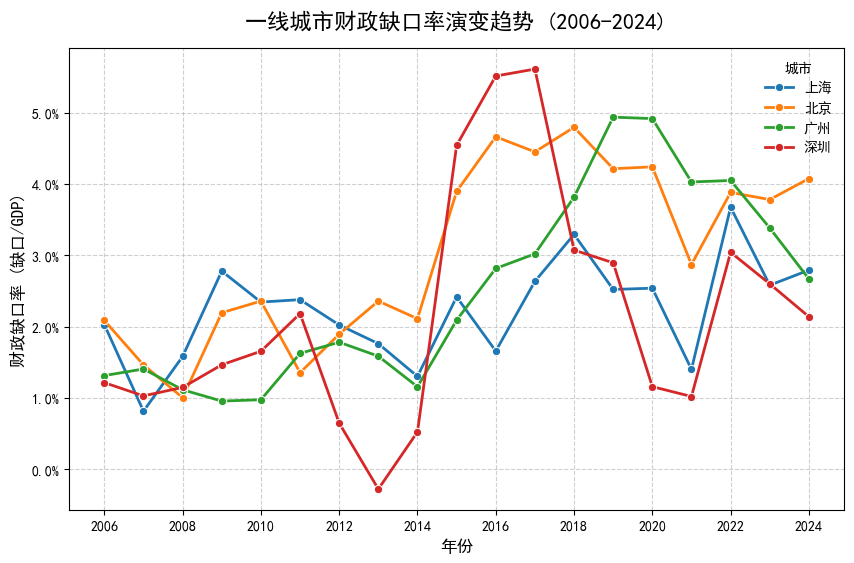

✅ 一线城市折线图已保存至: ..\output\tier1_gap_trend.png


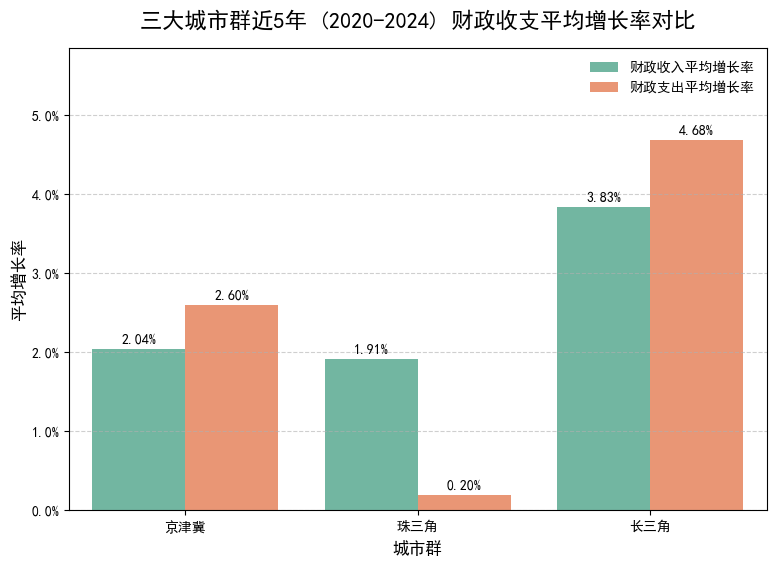

✅ 城市群柱状图已保存至: ..\output\clusters_growth_bar.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os
import warnings

# 忽略无关警告，避免输出干扰
warnings.filterwarnings('ignore')

# ======================== 基础配置 ========================
# 设置中文字体（兼容Windows/Mac/Linux）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
plt.rcParams['figure.dpi'] = 100  # 默认显示分辨率
plt.rcParams['savefig.dpi'] = 300  # 保存图片高分辨率

# 定义路径（增加路径检查和自动创建）
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')
OUTPUT_DIR = os.path.join('..', 'output')

# 创建输出目录（如果不存在）
os.makedirs(CLEAN_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ======================== 数据读取与预处理 ========================
try:
    # 读取数据
    df = pd.read_csv(os.path.join(CLEAN_DATA_DIR, 'enhanced_core_data.csv'))
    
    # 核心优化：将year列转为整数（解决横坐标.0问题的根本方法）
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('int64')
    
    # 数据有效性检查
    if df.empty:
        raise ValueError("读取的数据集为空，请检查文件路径和文件内容")
    required_cols = ['year', 'city', 'gap_to_gdp', 'income_growth', 'expend_growth']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise KeyError(f"数据缺少必要列：{', '.join(missing_cols)}，请检查数据文件")
        
except FileNotFoundError:
    print(f"❌ 错误：未找到文件 {os.path.join(CLEAN_DATA_DIR, 'enhanced_core_data.csv')}")
    exit(1)
except Exception as e:
    print(f"❌ 数据读取/预处理失败：{str(e)}")
    exit(1)

# ======================== 任务 4.1：一线城市财政缺口率趋势（折线图） ========================
tier1_cities = ['北京', '上海', '广州', '深圳']
df_tier1 = df[df['city'].isin(tier1_cities)].copy()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_tier1, x='year', y='gap_to_gdp', hue='city', marker='o', linewidth=2)

# 标题和标签设置
plt.title('一线城市财政缺口率演变趋势 (2006-2024)', fontsize=16, pad=15)
plt.xlabel('年份', fontsize=12)
plt.ylabel('财政缺口率 (缺口/GDP)', fontsize=12)

# Y轴百分比格式 + X轴整数刻度（双重保障）
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='城市', frameon=False)  # 去掉图例边框更美观

# 保存图表
line_chart_path = os.path.join(OUTPUT_DIR, 'tier1_gap_trend.png')
plt.savefig(line_chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ 一线城市折线图已保存至: {line_chart_path}")

# ======================== 任务 4.2：三大城市群近5年收支增长率（柱状图） ========================
# 定义城市群
clusters = {
    '京津冀': ['北京', '天津', '石家庄'],
    '长三角': ['上海', '南京', '杭州', '合肥', '宁波'],
    '珠三角': ['广州', '深圳']
}

# 映射城市群标签
df['cluster'] = df['city'].apply(lambda x: next((k for k, v in clusters.items() if x in v), None))

# 筛选近5年（2020-2024）且属于三大城市群的数据
df_recent = df[(df['year'] >= 2020) & (df['year'] <= 2024) & (df['cluster'].notna())].copy()

# 计算各城市群的平均增长率
cluster_growth = df_recent.groupby('cluster')[['income_growth', 'expend_growth']].mean().reset_index()

# 宽表转长表，方便 seaborn 画分组柱状图
cluster_melted = cluster_growth.melt(
    id_vars='cluster',
    value_vars=['income_growth', 'expend_growth'],
    var_name='指标',
    value_name='平均增长率'
)

# 替换图例名称
cluster_melted['指标'] = cluster_melted['指标'].replace({
    'income_growth': '财政收入平均增长率',
    'expend_growth': '财政支出平均增长率'
})

# 绘制柱状图
plt.figure(figsize=(9, 6))
ax = sns.barplot(data=cluster_melted, x='cluster', y='平均增长率', hue='指标', palette='Set2')

# 核心优化：在每个柱子上方添加增长率数值（格式统一+位置优化）
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f'{x*100:.2f}%',  # 统一为百分比格式（如2.50%）
        padding=3,                       # 标签与柱子顶部距离
        fontsize=10,                     # 字体大小
        color='black',                   # 字体颜色
        fontweight='bold'                # 加粗提升辨识度
    )

# 标题和标签设置
plt.title('三大城市群近5年 (2020-2024) 财政收支平均增长率对比', fontsize=16, pad=15)
plt.xlabel('城市群', fontsize=12)
plt.ylabel('平均增长率', fontsize=12)

# Y轴百分比格式 + 调整Y轴范围（避免数值标签超出图表）
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
y_max = cluster_melted['平均增长率'].max()
plt.ylim(0, y_max * 1.25)  # 预留足够空间给数值标签

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='', frameon=False)

# 保存图表
bar_chart_path = os.path.join(OUTPUT_DIR, 'clusters_growth_bar.png')
plt.savefig(bar_chart_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ 城市群柱状图已保存至: {bar_chart_path}")

- 生成图表的同时将数据以表格的形式呈现

In [7]:
import pandas as pd
import os

# 定义路径
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')
OUTPUT_DIR = os.path.join('..', 'output')

# 读取带有指标的数据
df = pd.read_csv(os.path.join(CLEAN_DATA_DIR, 'enhanced_core_data.csv'))

# ==========================================
# 表格 1：一线城市财政缺口率明细表 (2006-2024)
# ==========================================
tier1_cities = ['北京', '上海', '广州', '深圳']
df_tier1 = df[df['city'].isin(tier1_cities)].copy()

# 使用透视表，将年份作为行，城市作为列
tier1_pivot = df_tier1.pivot(index='year', columns='city', values='gap_to_gdp')

# 将小数格式化为百分比
for col in tier1_pivot.columns:
    tier1_pivot[col] = tier1_pivot[col].apply(lambda x: f"{x:.2%}" if pd.notna(x) else "")

# 重置索引以便保存
tier1_pivot = tier1_pivot.reset_index()
tier1_pivot.rename(columns={'year': '年份'}, inplace=True)

# 保存表格
tier1_table_path = os.path.join(OUTPUT_DIR, 'tier1_gap_trend_table.csv')
tier1_pivot.to_csv(tier1_table_path, index=False, encoding='utf-8-sig')
print(f"✅ 一线城市缺口率明细表已保存至: {tier1_table_path}")
display(tier1_pivot.head()) # 展示前几行预览

# ==========================================
# 表格 2：三大城市群近5年收支平均增长率
# ==========================================
# 定义城市群
clusters = {
    '京津冀': ['北京', '天津', '石家庄'],
    '长三角': ['上海', '南京', '杭州', '合肥', '宁波'],
    '珠三角': ['广州', '深圳']
}

def get_cluster(city):
    for cluster_name, city_list in clusters.items():
        if city in city_list:
            return cluster_name
    return None

df['cluster'] = df['city'].apply(get_cluster)

# 筛选近5年数据并计算平均值
df_recent = df[(df['year'] >= 2020) & (df['year'] <= 2024) & (df['cluster'].notna())]
cluster_growth = df_recent.groupby('cluster')[['income_growth', 'expend_growth']].mean().reset_index()

# 格式化为百分比并重命名列
cluster_growth['income_growth'] = cluster_growth['income_growth'].apply(lambda x: f"{x:.2%}" if pd.notna(x) else "")
cluster_growth['expend_growth'] = cluster_growth['expend_growth'].apply(lambda x: f"{x:.2%}" if pd.notna(x) else "")
cluster_growth.rename(columns={
    'cluster': '城市群', 
    'income_growth': '近5年财政收入平均增长率', 
    'expend_growth': '近5年财政支出平均增长率'
}, inplace=True)

# 保存表格
cluster_table_path = os.path.join(OUTPUT_DIR, 'clusters_growth_table.csv')
cluster_growth.to_csv(cluster_table_path, index=False, encoding='utf-8-sig')
print(f"\n✅ 三大城市群增长率明细表已保存至: {cluster_table_path}")
display(cluster_growth)


✅ 一线城市缺口率明细表已保存至: ..\output\tier1_gap_trend_table.csv


city,年份,上海,北京,广州,深圳
0,2006,2.03%,2.08%,1.31%,1.21%
1,2007,0.81%,1.46%,1.41%,1.03%
2,2008,1.58%,1.00%,1.11%,1.15%
3,2009,2.78%,2.19%,0.96%,1.46%
4,2010,2.34%,2.36%,0.97%,1.65%



✅ 三大城市群增长率明细表已保存至: ..\output\clusters_growth_table.csv


,城市群,近5年财政收入平均增长率,近5年财政支出平均增长率
0,京津冀,2.04%,2.60%
1,珠三角,1.91%,0.20%
2,长三角,3.83%,4.68%


# 阶段性结论分析

1. 一线城市财政缺口率演变（2006-2024）
- 从折线图（tier1_gap_trend.png）和明细表中可以看出，四大一线城市的财政缺口率在过去近二十年间呈现出显著的分化与波动：

  - 深圳的“过山车”特征：深圳在 2013-2014 年间是唯一实现财政盈余（缺口率为负，如 2013 年的 -0.28%）的城市，展现了极强的财政自给能力。但自 2015 年起，随着城市建设和公共服务投入的加大，其缺口率迅速攀升，并在 2017 年达到峰值（5.61%）。
  - 北京与广州的高位运行：北京和广州的财政缺口率整体处于较高水平。特别是北京，近年来（2016年之后）的缺口率基本稳定在 3.5% - 4.8% 之间，这与其作为首都，承担了大量非经济性的公共服务与基础设施建设职能密切相关。
  - 上海的稳健底色：上海的财政缺口率波动相对平缓，长期维持在 1.5% - 3.5% 的区间内，展现了极其稳定的财政收入基本盘和极强的抗风险能力。
2. 三大城市群近5年收支增长率对比（2020-2024）
- 柱状图（clusters_growth_bar.png）揭示了在近几年的宏观经济环境下，中国三大核心经济引擎在财政策略上的不同侧重：

  - 长三角的“双轮驱动”：长三角城市群（以上海、杭州、南京等为代表）不仅财政收入平均增长率最高（接近 4.00%），其财政支出平均增长率也位居榜首（超过 4.50%）。这表明长三角地区在保持强劲经济活力的同时，正在实施积极的扩张性财政政策。
  - 京津冀的“稳中求进”：京津冀地区的收入与支出增长率均保持在 2.00% - 2.60% 左右的适中水平，财政收支步调相对一致，政策导向偏向稳健。
  - 珠三角的“量入为出”：以广深为代表的珠三角地区，其财政收入平均增长率接近 2.00%，但财政支出平均增长率极低（不足 0.50%）。这反映出该地区近五年来在财政支出上采取了极为谨慎和保守的策略，注重控制债务和财政安全。

# 房地产关联内容分析
# 整体研究框架设计
- 本探索将分为四个核心阶段推进，从基础数据处理到深度的时空特征剖析。

 1. 数据清洗与多维融合
 - 目标：将6个房地产维度的宽表数据清洗为长表，并与前一阶段生成的 enhanced_core_data.csv 进行主键（城市、年份）合并，构建完整的面板数据底座。
 2. 特征工程与衍生指标构建
 - 目标：绝对数值难以跨城市比较，需要构建反映“房地产依赖度”与“市场热度”的相对指标。
 3. 时序特征分析 (Temporal Analysis)
 - 目标：观察房地产周期的起伏如何传导至地方财政缺口。
 - 方法：划分关键宏观调控周期（如2006-2015年的稳步增长期，2016-2020年的棚改去库存爆发期，2021年至今的深度调整期），对比不同阶段下缺口率与地产指标的联动关系。
 4. 地区差异与象限分析 (Spatial Analysis)
 - 目标：识别不同城市的财政-地产发展模式。
 - 方法：利用散点图与象限划分，将城市归类为“高依赖-低缺口”（传统土地财政强市）、“低依赖-高缺口”（产业转型滞后市）等不同类型。

## 拟构建指标：
- 房地产投资依赖度 = 房地产开发投资额 / GDP
- 市场景气指数 = 商品房销售面积 × 商品房平均销售价格（估算销售额）的年度增长率
- 土地购置活跃度 = 购置土地面积的年度变化

# 核心维度与计划方案
- 核心指标形态
  - 构建相对比率与强度指标
  - 理由：消除一线与二三线城市的体量差异，更准确反映经济结构特征。
- 时序分析切入点
  - 引入宏观周期分阶段分析
  - 理由：房地产受政策周期影响极大，分阶段能精准捕捉“政策-市场-财政”的传导滞后性。
- 地区差异呈现
  - 采用散点矩阵与象限聚类图
  - 理由：能直观呈现单个城市在“地产依赖度”与“财政缺口率”二维空间中的生态位演变。

# 第一阶段 数据融合


In [8]:
import pandas as pd
import numpy as np
import os
import re

# 定义路径
RAW_DATA_DIR = os.path.join('..', 'data_raw')
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')

# 房地产文件与变量名映射
real_estate_files = {
    're_sales_area.xlsx': 're_sales_area',
    're_avg_price.xlsx': 're_avg_price',
    're_completion.xlsx': 're_completion',
    're_construction.xlsx': 're_construction',
    're_dev_inv.xlsx': 're_dev_inv',
    're_land_purchase_area.xlsx': 're_land_purchase_area'
}

def process_nbs_excel(file_name, value_col_name):
    """处理国家统计局Excel宽表数据"""
    file_path = os.path.join(RAW_DATA_DIR, file_name)
    
    # 自动寻找表头行
    df_raw = pd.read_excel(file_path, header=None, nrows=10)
    header_idx = 0
    for i in range(len(df_raw)):
        row_str = ' '.join(df_raw.iloc[i].astype(str).tolist())
        if len(re.findall(r'20\d{2}', row_str)) >= 3:
            header_idx = i
            break
            
    df = pd.read_excel(file_path, skiprows=header_idx)
    
    # 清理非数据行
    first_col = df.columns[0]
    df = df.dropna(subset=[first_col])
    df = df[~df[first_col].astype(str).str.contains('注|来源|统计局|指标|时间')]
    df.rename(columns={first_col: 'city'}, inplace=True)
    
    # 宽表转长表
    df_long = df.melt(id_vars=['city'], var_name='year', value_name=value_col_name)
    
    # 提取年份并清洗
    df_long['year'] = df_long['year'].astype(str).str.extract(r'(\d{4})')
    df_long = df_long.dropna(subset=['year'])
    df_long['year'] = df_long['year'].astype(int)
    
    # 清洗城市名称
    df_long['city'] = df_long['city'].astype(str).str.replace(r'\s+', '', regex=True)
    df_long['city'] = df_long['city'].str.replace('市', '')
    
    # 数值化处理
    df_long[value_col_name] = pd.to_numeric(df_long[value_col_name], errors='coerce')
    
    return df_long

# 1. 读取之前已清洗的基础财务数据
base_data_path = os.path.join(CLEAN_DATA_DIR, 'enhanced_core_data.csv')
master_df = pd.read_csv(base_data_path)

# 2. 循环处理房地产数据并逐步合并
for file_name, col_name in real_estate_files.items():
    file_path = os.path.join(RAW_DATA_DIR, file_name)
    if os.path.exists(file_path):
        print(f"正在处理房地产指标: {col_name} ...")
        temp_df = process_nbs_excel(file_name, col_name)
        # 使用左连接，以基础财务数据的城市和年份为准
        master_df = pd.merge(master_df, temp_df, on=['city', 'year'], how='left')
    else:
        print(f"警告：未找到文件 {file_name}")

# 3. 保存最终的大宽表面板数据
master_output_path = os.path.join(CLEAN_DATA_DIR, 'master_panel_data.csv')
master_df.to_csv(master_output_path, index=False, encoding='utf-8-sig')

print(f"\n数据融合完成！包含财务与房地产全指标的面板数据已保存至: {master_output_path}")
print(f"当前数据维度: {master_df.shape}")


正在处理房地产指标: re_sales_area ...
正在处理房地产指标: re_avg_price ...
正在处理房地产指标: re_completion ...
正在处理房地产指标: re_construction ...
正在处理房地产指标: re_dev_inv ...
正在处理房地产指标: re_land_purchase_area ...

数据融合完成！包含财务与房地产全指标的面板数据已保存至: ..\data_clean\master_panel_data.csv
当前数据维度: (720, 15)


# 第二阶段 特征工程与衍生指标构建
## 核心决策点与推荐方案

- 指标方案
  1. 房地产投资依赖度 (re_invest_dependence)
   - 计算公式：re_dev_inv (房地产开发投资额) / gdp
   - 经济学含义：衡量该城市经济增长对房地产前端开发投资的依赖程度。该指标过高通常意味着产业结构单一，一旦投资放缓，可能对地方经济和财政造成冲击。
  2. 估算商品房销售额 (re_sales_value)
   - 计算公式：(re_sales_area * re_avg_price) / 10000
   - 单位换算逻辑：销售面积（万平方米）乘以 均价（元/平方米）得出的是“万元”，除以10000后统一转化为“亿元”，以便与GDP和财政收支的单位保持一致。
  3. 房地产销售活跃度 (re_sales_dependence)
   - 计算公式：re_sales_value / gdp
   - 经济学含义：衡量城市房地产市场的资金流动性及居民加杠杆的程度。销售端活跃通常能直接带动契税、增值税等地方税收，从而缓解财政缺口。
  4. 土地购置活跃度 (land_purchase_growth)
   - 计算公式：re_land_purchase_area 的年度同比增长率
   - 经济学含义：反映开发商对该城市未来的预期。土地购置是地方政府“土地财政”（政府性基金预算收入）的核心来源，该指标的剧烈波动往往是财政缺口扩大的前兆。

In [9]:
import pandas as pd
import numpy as np
import os

# 定义路径
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')
input_file = os.path.join(CLEAN_DATA_DIR, 'master_panel_data.csv')

# 读取数据
df = pd.read_csv(input_file)

# 确保按城市和年份排序，以便计算增速
df = df.sort_values(by=['city', 'year']).reset_index(drop=True)

# 1. 房地产投资依赖度 (投资额 / GDP)
# 注：re_dev_inv 和 gdp 的单位均为 亿元
df['re_invest_dependence'] = df['re_dev_inv'] / df['gdp']

# 2. 估算商品房销售额 (单位：亿元)
# 面积(万平米) * 均价(元/平米) / 10000 = 亿元
df['re_sales_value'] = (df['re_sales_area'] * df['re_avg_price']) / 10000

# 3. 房地产销售活跃度 (销售额 / GDP)
df['re_sales_dependence'] = df['re_sales_value'] / df['gdp']

# 4. 土地购置活跃度 (土地购置面积年度增速)
df['land_purchase_growth'] = df.groupby('city')['re_land_purchase_area'].pct_change()

# 处理可能出现的无穷大值 (如除以0的情况)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 保存包含衍生指标的新面板数据
output_file = os.path.join(CLEAN_DATA_DIR, 'engineered_panel_data.csv')
df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"特征工程完成！衍生指标已添加，文件保存至: {output_file}")
print("新增字段预览:")
print(df[['city', 'year', 're_invest_dependence', 're_sales_value', 're_sales_dependence', 'land_purchase_growth']].head())


特征工程完成！衍生指标已添加，文件保存至: ..\data_clean\engineered_panel_data.csv
新增字段预览:
  city  year  re_invest_dependence  re_sales_value  re_sales_dependence  \
0   上海  2006              0.117833     2177.077840             0.201108   
1   上海  2007              0.099207     3089.356056             0.234401   
2   上海  2008              0.096506     1917.048155             0.128859   
3   上海  2009              0.090355     4330.225800             0.267605   
4   上海  2010              0.108118     2980.972544             0.162720   

   land_purchase_growth  
0                   NaN  
1             -0.730364  
2              1.307410  
3             -0.433386  
4              1.338308  


C:\Users\CONG\AppData\Local\Temp\ipykernel_6284\3326498905.py:27: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['land_purchase_growth'] = df.groupby('city')['re_land_purchase_area'].pct_change()


# 第三阶段 时序特征分析 (Temporal Analysis)
- 核心目标：探究宏观房地产周期的起伏，是如何传导并影响地方财政缺口率
## 核心决策点与推荐方案
  - 周期划分：按中国房地产宏观调控周期划分
    - 房地产受政策驱动明显。计划划分为三段：
    1. 2006-2015：稳步增长与刺激期
    2. 2016-2020：棚改货币化与“房住不炒”提出期
    3. 2021-2024：深度调整与去杠杆期
  
  - 可视化形式：双Y轴折线图配合周期阴影
    - 将“财政缺口率”与“房地产依赖度”放在同一张图的双轴上，辅以背景阴影区分周期，能最直观地观察两者的同步性或滞后性。
  
  - 分析样本：宏观全景（整体均值/分布）+ 微观切片（典型个体）
    - 样本从东中西部各选3个城市
      - 东部代表：杭州、南京、广州（土地财政与经济活力双强）
      - 中部代表：郑州、武汉、长沙（强省会战略与基建扩张典型）
      - 西部代表：成都、西安、兰州（人口流入与产业转移承接地）



In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

# 设置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义路径
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')
OUTPUT_DIR = os.path.join('..', 'output')
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 1. 读取数据并剔除2025年空值
input_file = os.path.join(CLEAN_DATA_DIR, 'engineered_panel_data.csv')
df = pd.read_csv(input_file)
df = df[df['year'] <= 2024].copy()

# 2. 计算全国大盘均值 (Macro)
df_macro = df.groupby('year')[['gap_to_gdp', 're_invest_dependence']].mean().reset_index()

# 3. 定义东中西部 9 个典型城市
target_cities = {
    '东部': ['杭州', '南京', '广州'],
    '中部': ['郑州', '武汉', '长沙'],
    '西部': ['成都', '西安', '兰州']
}
# 展平城市列表
all_target_cities = [city for region in target_cities.values() for city in region]

# 4. 导出数据表格
# 导出大盘数据
macro_out_path = os.path.join(OUTPUT_DIR, 'macro_trend_data.csv')
df_macro.to_csv(macro_out_path, index=False, encoding='utf-8-sig')

# 导出9个城市的数据
df_slices = df[df['city'].isin(all_target_cities)][['city', 'year', 'gap_to_gdp', 're_invest_dependence']]
slices_out_path = os.path.join(OUTPUT_DIR, 'city_slices_trend_data.csv')
df_slices.to_csv(slices_out_path, index=False, encoding='utf-8-sig')
print(f"数据表格已导出至 output 文件夹:\n1. {macro_out_path}\n2. {slices_out_path}\n")

# 5. 定义“同框对比”绘图函数
def plot_comparative_trend(city_name, region_name, city_data, macro_data):
    fig, ax1 = plt.subplots(figsize=(12, 6.5))

    # 背景宏观周期阴影
    ax1.axvspan(2006, 2015, color='grey', alpha=0.1, label='稳步增长与刺激期 (2006-2015)')
    ax1.axvspan(2016, 2020, color='blue', alpha=0.05, label='棚改与调控期 (2016-2020)')
    ax1.axvspan(2021, 2024, color='red', alpha=0.05, label='深度调整期 (2021-2024)')

    # --- 左轴：财政缺口率 ---
    color_gap_city = '#1f77b4'  # 深蓝
    color_gap_macro = '#8fbede' # 浅蓝
    ax1.set_xlabel('年份', fontsize=12)
    ax1.set_ylabel('财政缺口率 (缺口/GDP)', color=color_gap_city, fontsize=12)
    
    # 城市线 (实线)
    line1 = ax1.plot(city_data['year'], city_data['gap_to_gdp'], color=color_gap_city, marker='o', linewidth=2.5, label=f'{city_name} 缺口率')
    # 大盘线 (虚线)
    line2 = ax1.plot(macro_data['year'], macro_data['gap_to_gdp'], color=color_gap_macro, linestyle='--', linewidth=2, label='全国均值 缺口率')
    
    ax1.tick_params(axis='y', labelcolor=color_gap_city)
    ax1.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

    # --- 右轴：房地产投资依赖度 ---
    ax2 = ax1.twinx()
    color_re_city = '#ff7f0e'   # 深橙
    color_re_macro = '#ffbb78'  # 浅橙
    ax2.set_ylabel('房地产投资依赖度 (投资额/GDP)', color=color_re_city, fontsize=12)
    
    # 城市线 (实线)
    line3 = ax2.plot(city_data['year'], city_data['re_invest_dependence'], color=color_re_city, marker='s', linewidth=2.5, label=f'{city_name} 地产依赖度')
    # 大盘线 (虚线)
    line4 = ax2.plot(macro_data['year'], macro_data['re_invest_dependence'], color=color_re_macro, linestyle='--', linewidth=2, label='全国均值 地产依赖度')
    
    ax2.tick_params(axis='y', labelcolor=color_re_city)
    ax2.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

    # --- 合并图例 ---
    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    handles, shadow_labels = ax1.get_legend_handles_labels()
    # 将阴影图例和线条图例合并，放在图表外部上方，避免遮挡数据
    ax1.legend(lines + handles[:3], labels + shadow_labels[:3], loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)

    plt.title(f'【{region_name}代表】{city_name} vs 全国均值：财政与地产时序演变对比', fontsize=15, pad=15)
    plt.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.tight_layout()
    output_path = os.path.join(OUTPUT_DIR, f'comparative_trend_{region_name}_{city_name}.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"已生成同框对比图: {output_path}")

# 6. 循环绘制9个城市的对比图
print("开始生成 9 个典型城市的同框对比图表...")
for region, cities in target_cities.items():
    for city in cities:
        city_data = df[df['city'] == city].copy()
        if not city_data.empty:
            plot_comparative_trend(city, region, city_data, df_macro)
        else:
            print(f"警告：未找到 {city} 的数据。")

print("\n第三阶段：时序特征分析（表格+同框对比图）全部生成完毕！")


数据表格已导出至 output 文件夹:
1. ..\output\macro_trend_data.csv
2. ..\output\city_slices_trend_data.csv

开始生成 9 个典型城市的同框对比图表...
已生成同框对比图: ..\output\comparative_trend_东部_杭州.png
已生成同框对比图: ..\output\comparative_trend_东部_南京.png
已生成同框对比图: ..\output\comparative_trend_东部_广州.png
已生成同框对比图: ..\output\comparative_trend_中部_郑州.png
已生成同框对比图: ..\output\comparative_trend_中部_武汉.png
已生成同框对比图: ..\output\comparative_trend_中部_长沙.png
已生成同框对比图: ..\output\comparative_trend_西部_成都.png
已生成同框对比图: ..\output\comparative_trend_西部_西安.png
已生成同框对比图: ..\output\comparative_trend_西部_兰州.png

第三阶段：时序特征分析（表格+同框对比图）全部生成完毕！


# 第四阶段：空间维度的象限聚类分析
- 本阶段将解答“空间上的结构差异”。通过构建二维散点图，我们可以将35个城市划分为不同的生态位，识别出哪些城市面临最大的转型阵痛，哪些城市已经成功摆脱了土地依赖。
  
## 关键决策与方案
- 时间截面选择：选取 2021-2024 年的均值
  - 单一年度数据（如仅看2024年）容易受偶然因素干扰。取“深度调整期”的均值，能最准确地反映城市当前的真实抗压底色。
- 坐标轴设定：X轴：房地产投资依赖度<br>Y轴：财政缺口率
  - X轴代表对传统模式的依赖，Y轴代表财政健康的现状。
- 象限划分基准：以35城的“中位数”为十字交叉线
  - 相比于绝对零点或平均值，中位数能不受极端极值（如个别缺口极大的城市）影响，将城市均匀地划分为四类典型模式。

象限经济含义定义
- 第一象限（右上，双高）：高依赖-高缺口（转型阵痛区）。过去高度依赖地产，目前财政压力极大。
- 第二象限（左上，低高）：低依赖-高缺口（内生乏力区）。地产依赖虽低，但其他产业也未能提供足够税源。
- 第三象限（左下，双低）：低依赖-低缺口（健康发展区）。已摆脱地产依赖，且财政自给率高（通常是一线或强二线）。 
- 第四象限（右下，高低）：高依赖-低缺口（传统红利区）。仍能靠地产维持较好的财政平衡，但面临潜在风险。

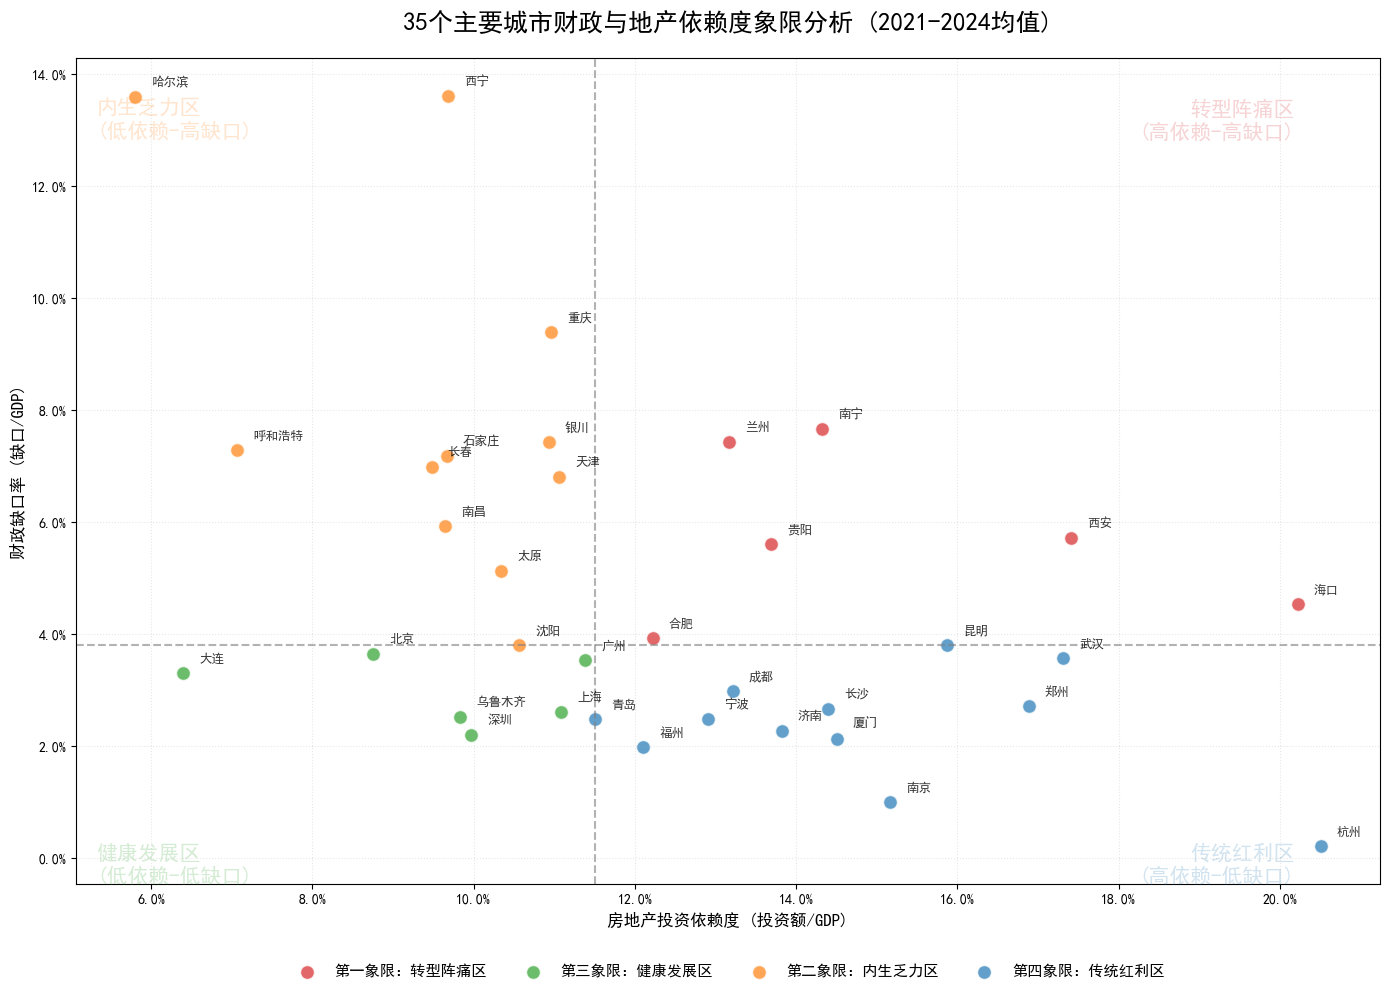


 📊 35个主要城市象限分类结果 (2021-2024均值)

📍 第一象限：转型阵痛区 (高依赖-高缺口)
----------------------------------------
城市 财政缺口率  地产依赖度
南宁 7.66% 14.32%
兰州 7.44% 13.17%
西安 5.72% 17.41%
贵阳 5.60% 13.69%
海口 4.54% 20.22%
合肥 3.92% 12.22%

📍 第三象限：健康发展区 (低依赖-低缺口)
----------------------------------------
  城市 财政缺口率  地产依赖度
  北京 3.65%  8.75%
  广州 3.53% 11.38%
  大连 3.29%  6.39%
  上海 2.61% 11.08%
乌鲁木齐 2.52%  9.83%
  深圳 2.20%  9.97%

📍 第二象限：内生乏力区 (低依赖-高缺口)
----------------------------------------
  城市  财政缺口率  地产依赖度
  西宁 13.61%  9.68%
 哈尔滨 13.59%  5.80%
  重庆  9.39% 10.96%
  银川  7.43% 10.93%
呼和浩特  7.29%  7.07%
 石家庄  7.17%  9.67%
  长春  6.99%  9.48%
  天津  6.80% 11.06%
  南昌  5.92%  9.64%
  太原  5.13% 10.34%
  沈阳  3.80% 10.57%

📍 第四象限：传统红利区 (高依赖-低缺口)
----------------------------------------
城市  财政缺口率  地产依赖度
拉萨 35.56%   nan%
昆明  3.80% 15.87%
武汉  3.57% 17.31%
成都  2.98% 13.22%
郑州  2.71% 16.89%
长沙  2.67% 14.40%
青岛  2.48% 11.51%
宁波  2.48% 12.90%
济南  2.27% 13.82%
厦门  2.13% 14.50%
福州  1.98% 12.10%
南京  1.00% 15.16%
杭州  0.21% 20.51%

✅ 文

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 设置中文字体与负号显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义路径
CLEAN_DATA_DIR = os.path.join('..', 'data_clean')
OUTPUT_DIR = os.path.join('..', 'output')

# 1. 读取数据
input_file = os.path.join(CLEAN_DATA_DIR, 'engineered_panel_data.csv')
df = pd.read_csv(input_file)

# 2. 截取“深度调整期” (2021-2024) 的数据并计算城市均值
df_recent = df[(df['year'] >= 2021) & (df['year'] <= 2024)]
city_summary = df_recent.groupby('city')[['gap_to_gdp', 're_invest_dependence']].mean().reset_index()

# 3. 计算十字交叉线的基准（中位数）
median_gap = city_summary['gap_to_gdp'].median()
median_re = city_summary['re_invest_dependence'].median()

# 4. 为城市打上象限标签
def assign_quadrant(row):
    if row['re_invest_dependence'] >= median_re and row['gap_to_gdp'] >= median_gap:
        return '第一象限：转型阵痛区 (高依赖-高缺口)'
    elif row['re_invest_dependence'] < median_re and row['gap_to_gdp'] >= median_gap:
        return '第二象限：内生乏力区 (低依赖-高缺口)'
    elif row['re_invest_dependence'] < median_re and row['gap_to_gdp'] < median_gap:
        return '第三象限：健康发展区 (低依赖-低缺口)'
    else:
        return '第四象限：传统红利区 (高依赖-低缺口)'

city_summary['quadrant'] = city_summary.apply(assign_quadrant, axis=1)

# 5. 绘制象限散点图
fig, ax = plt.subplots(figsize=(14, 10))

# 根据象限设置颜色
colors = {
    '第一象限：转型阵痛区 (高依赖-高缺口)': '#d62728', # 红
    '第二象限：内生乏力区 (低依赖-高缺口)': '#ff7f0e', # 橙
    '第三象限：健康发展区 (低依赖-低缺口)': '#2ca02c', # 绿
    '第四象限：传统红利区 (高依赖-低缺口)': '#1f77b4'  # 蓝
}

for quad, group in city_summary.groupby('quadrant'):
    ax.scatter(group['re_invest_dependence'], group['gap_to_gdp'], 
               c=colors[quad], s=100, alpha=0.7, edgecolors='white', label=quad.split(' ')[0])

# 添加城市名称标签
for i, row in city_summary.iterrows():
    ax.text(row['re_invest_dependence'] + 0.002, row['gap_to_gdp'] + 0.002, 
            row['city'], fontsize=9, alpha=0.8)

# 绘制中位数十字线
ax.axhline(median_gap, color='grey', linestyle='--', alpha=0.6)
ax.axvline(median_re, color='grey', linestyle='--', alpha=0.6)

# 格式化坐标轴为百分比
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# 添加象限背景文字
ax.text(ax.get_xlim()[1]*0.95, ax.get_ylim()[1]*0.95, '转型阵痛区\n(高依赖-高缺口)', 
        fontsize=15, color='#d62728', alpha=0.2, ha='right', va='top')
ax.text(ax.get_xlim()[0]*1.05, ax.get_ylim()[1]*0.95, '内生乏力区\n(低依赖-高缺口)', 
        fontsize=15, color='#ff7f0e', alpha=0.2, ha='left', va='top')
ax.text(ax.get_xlim()[0]*1.05, ax.get_ylim()[0]*1.05, '健康发展区\n(低依赖-低缺口)', 
        fontsize=15, color='#2ca02c', alpha=0.2, ha='left', va='bottom')
ax.text(ax.get_xlim()[1]*0.95, ax.get_ylim()[0]*1.05, '传统红利区\n(高依赖-低缺口)', 
        fontsize=15, color='#1f77b4', alpha=0.2, ha='right', va='bottom')

plt.title('35个主要城市财政与地产依赖度象限分析 (2021-2024均值)', fontsize=18, pad=20)
plt.xlabel('房地产投资依赖度 (投资额/GDP)', fontsize=12)
plt.ylabel('财政缺口率 (缺口/GDP)', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False, fontsize=11)
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plot_output_path = os.path.join(OUTPUT_DIR, 'quadrant_analysis_scatter.png')
plt.savefig(plot_output_path, dpi=300, bbox_inches='tight')

# 【新增】直接在终端/Notebook输出图表
plt.show()

# 6. 导出分类结果表格
csv_output_path = os.path.join(OUTPUT_DIR, 'city_quadrant_classification.csv')
city_summary = city_summary.sort_values(by=['quadrant', 'gap_to_gdp'], ascending=[True, False])
city_summary.to_csv(csv_output_path, index=False, encoding='utf-8-sig')

# 【新增】在终端格式化打印表格数据
print("\n" + "="*50)
print(" 📊 35个主要城市象限分类结果 (2021-2024均值)")
print("="*50)

# 转换为百分比字符串以提升终端阅读体验
display_df = city_summary.copy()
display_df['gap_to_gdp'] = display_df['gap_to_gdp'].apply(lambda x: f"{x:.2%}")
display_df['re_invest_dependence'] = display_df['re_invest_dependence'].apply(lambda x: f"{x:.2%}")

# 分象限打印
for quad in sorted(display_df['quadrant'].unique()):
    print(f"\n📍 {quad}")
    print("-" * 40)
    subset = display_df[display_df['quadrant'] == quad][['city', 'gap_to_gdp', 're_invest_dependence']]
    subset.columns = ['城市', '财政缺口率', '地产依赖度']
    print(subset.to_string(index=False))

print("\n" + "="*50)
print(f"✅ 文件已同步保存至:\n图表: {plot_output_path}\n表格: {csv_output_path}")


# 房地产关联内容分析核心洞察
通过对35个主要城市近20年数据的深度挖掘，得出了以下三个维度的核心结论：

1. 宏观趋势：房地产周期的“退潮”与地方财政的“承压”
   - 剪刀差现象加剧：
     - 从全景基准图可以看出，2021年之前，房地产投资依赖度与财政缺口率保持着一定程度的动态平衡。但进入“深度调整期（2021-2024）”后，全国均值呈现出明显的“剪刀差”——房地产投资依赖度断崖式下降（从高点近20%降至10%左右），而财政缺口率却在高位震荡甚至逆势攀升（逼近6%）。
   - 土地财政的底层逻辑生变：
     - 这表明，过去依靠“卖地收入-基建投资-经济增长-税收增加”的传统财政循环已经打破。房地产引擎的降温，直接导致了地方财政自给能力的普遍下滑。
2. 空间格局：城市抗压能力的“K型”分化
   - 韧性标杆（第三象限-健康发展区）：
     - 以深圳、上海、北京、大连为代表。这类城市已经提前完成了产业升级，对房地产投资的依赖较低（低于中位数），且财政缺口率保持在极低水平。它们凭借强大的高端制造和现代服务业，实现了真正的财政内生循环。
   - 阵痛焦点（第一象限-转型阵痛区）：
     - 以西安、兰州、南宁、贵阳为代表。这类城市过去高度依赖房地产拉动经济，在地产降温后，不仅投资引擎熄火，且缺乏替代性高附加值产业，导致财政缺口迅速扩大，面临最大的短期流动性压力。
   - 路径依赖（第四象限-传统红利区）：
     - 以杭州、南京、成都、武汉等强二线城市为代表。它们虽然财政缺口控制得较好，但依然维持着较高的房地产投资依赖度。这类城市正处于十字路口，亟需在地产红利彻底消退前，利用现有的财政宽裕度加速培育新质生产力。
3. 区域特征：东中西部的阶梯式落差
   - 东部城市：普遍具备较强的抗风险能力，大多集中在第三（健康）和第四（红利）象限。
   - 中部城市：呈现两极分化，部分强省会（如郑州、武汉）依靠规模效应维持在第四象限，但隐忧显现。
   - 西部与东北城市：高度集中在第一（阵痛）和第二（内生乏力，如哈尔滨、西宁）象限，面临“旧动能衰退、新动能未满”的双重挤压，对中央转移支付的依赖度将进一步上升。